
## (o_coke_rt) model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* o_coke_rt ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(28, 'o_coke_rt')






## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [4]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [5]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [6]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [7]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [8]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [9]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


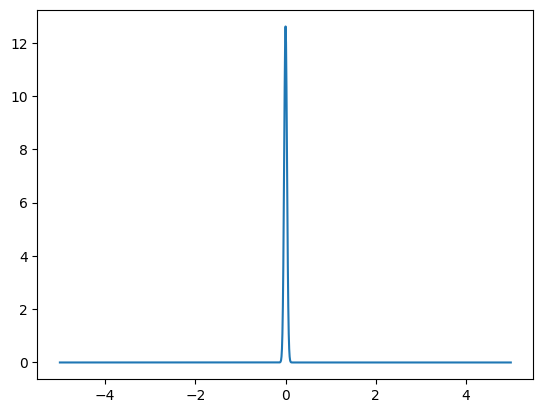

In [10]:

plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
plt.show()



## RUN KDE test


In [11]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [12]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.15.2025.csv')


In [13]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.7,45.4,145.0,312.0,821.0,24.2,22.6,57.4,4790.0,1890.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,17.9,30.2,160.0,345.0,930.0,40.7,17.0,57.6,5290.0,1910.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,18.2,39.1,191.0,413.0,1140.0,25.8,19.1,53.2,6330.0,2040.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1600,...,19.6,29.6,166.0,360.0,977.0,40.3,16.5,58.8,5510.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,4184,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-0_H2T-600_HBT...,50,0,0,0,30,0,600,1600,...,18.3,40.2,336.0,726.0,2100.0,30.8,25.3,58.0,11100.0,2630.0
4184,4185,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1200,...,19.4,39.9,295.0,638.0,1790.0,32.9,28.1,57.7,9790.0,2200.0
4185,4186,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,18.1,42.0,295.0,639.0,1800.0,33.4,28.3,58.4,9780.0,2360.0
4186,4187,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,19.6,39.6,295.0,638.0,1800.0,33.3,28.2,58.3,9790.0,2310.0


In [14]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_COH2ratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_COH2ratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


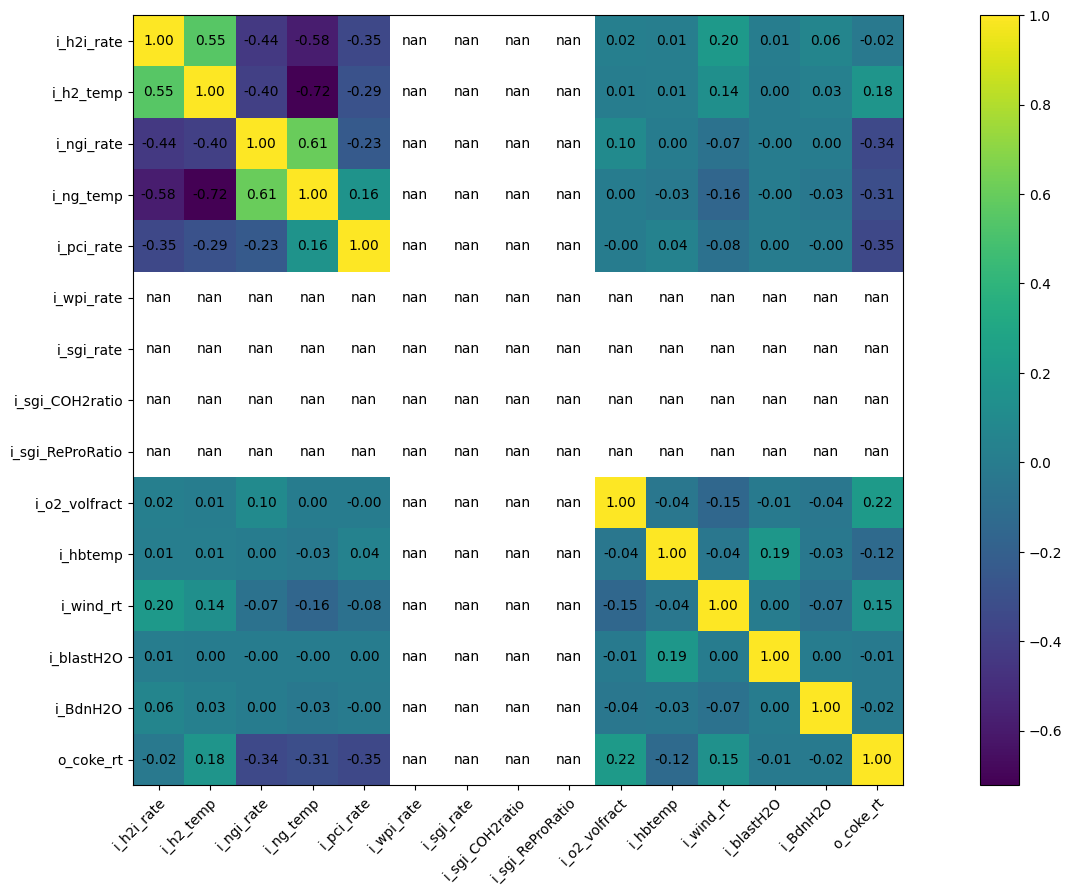

In [15]:

PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_COH2ratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O','o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [16]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 60.6 4060.0 1850.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-230_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.4 4790.0 1890.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1480_WR-160_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.6 5290.0 1910.0]
 ...
 [4186
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-0_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.4 9780.0 2360.0]
 [4187
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.3 9790.0 2310.0]
 [4188
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1600_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 57.9 9780.0 2400.0]]
(4188, 41)



## Select inputs and outputs


In [17]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 28 ]   
)







14
1


In [18]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4188, 14)
(4188, 1)


In [19]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [20]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3350, 14)
(838, 14)
(3350, 1)
(838, 1)


In [21]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [22]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [23]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [24]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [25]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [26]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [31]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = "o_coke_rt"


0  loss=  tensor(0.1951, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.0647, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0564, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.3169, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0128, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(1.4611, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.0287, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0709, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0223, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0091, grad_fn=<MseLossBackward0>)


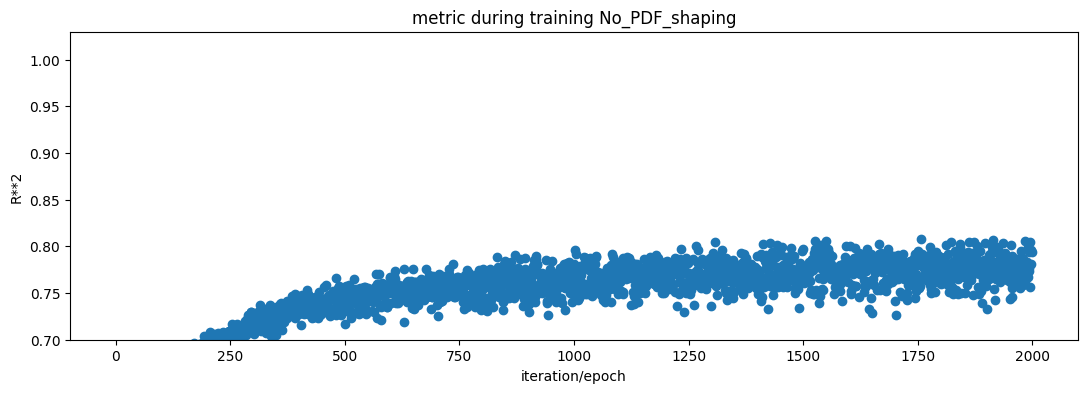

Training loss: tensor(0.2005, grad_fn=<MseLossBackward0>)
Training R**2: 0.7508305722454619
Test loss - scaled: tensor(0.0825, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(252.9127, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.8926454101619363
Testing R**2 - descaled: 0.8926454153157027
*****
*****
Testing R**2 - Output: 0 o_coke_rt 0.8926454153157027


In [28]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [29]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(419.4395, 432.0)
**************************************************
preds, real
(431.60168, 424.0)
**************************************************
preds, real
(491.12933, 489.0)
**************************************************
preds, real
(322.19208, 323.0)
**************************************************
preds, real
(453.96634, 448.0)
**************************************************
preds, real
(428.46735, 424.0)
**************************************************
preds, real
(460.5823, 443.0)
**************************************************
preds, real
(422.28232, 413.0)
**************************************************
preds, real
(429.73706, 429.0)
**************************************************
preds, real
(437.87405, 435.0)
**************************************************
preds, real
(413.3089, 407.0)
**************************************************
preds, real
(343.91385, 344.0)
*******************

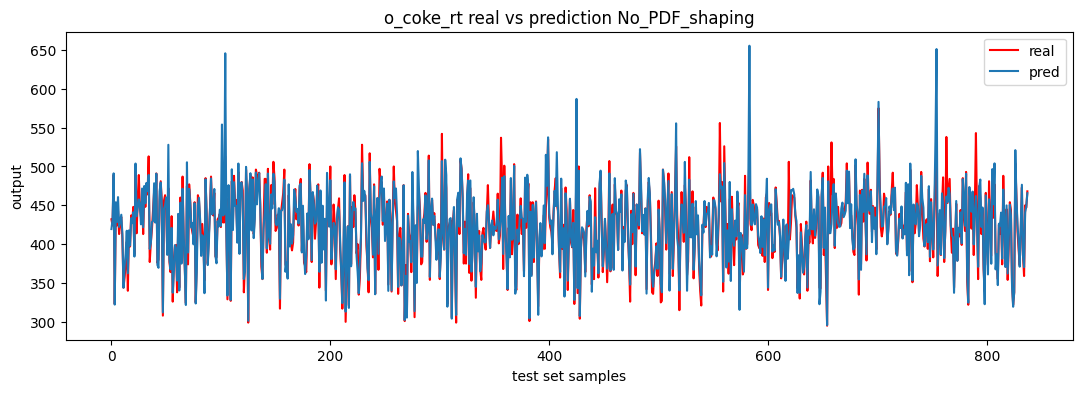

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


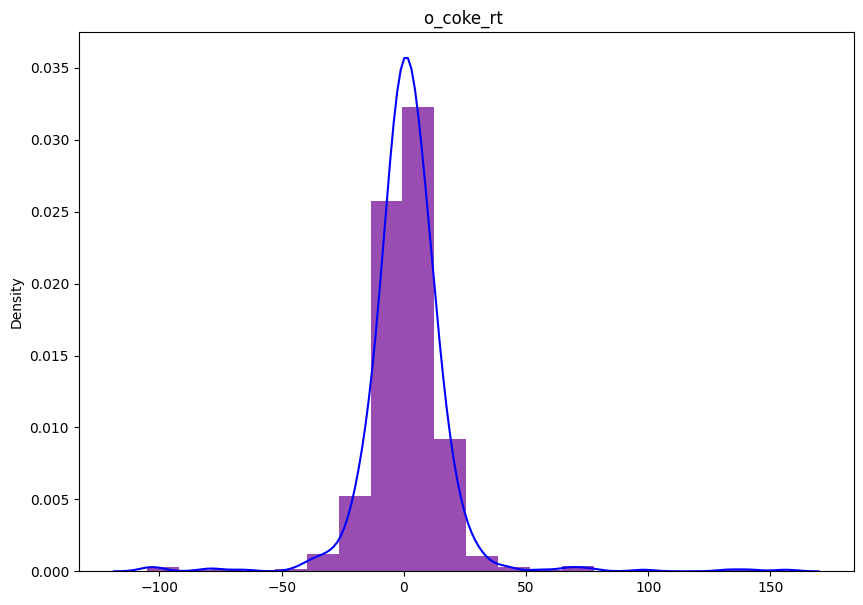

In [30]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## Export ONNX model


In [32]:


model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/F1plusF2NNs_o_coke_rt.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [33]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [34]:

pred_descaled


tensor([[420.8071],
        [455.7730],
        [483.1890],
        [326.8361],
        [449.3191],
        [420.8925],
        [463.1218],
        [424.0255],
        [434.1638],
        [436.7434],
        [413.9043],
        [348.8950],
        [361.0093],
        [386.3891],
        [414.9026],
        [356.5659],
        [409.4078],
        [400.2438],
        [434.5959],
        [431.3466],
        [440.9423],
        [387.0321],
        [494.7294],
        [430.9863],
        [446.8281],
        [457.3371],
        [451.3730],
        [425.9047],
        [471.6306],
        [409.5520],
        [470.5276],
        [447.6421],
        [480.8392],
        [471.5077],
        [486.0893],
        [390.0069],
        [405.9907],
        [423.3457],
        [432.5512],
        [477.9451],
        [430.2507],
        [473.9711],
        [377.6227],
        [381.1110],
        [464.6865],
        [479.3822],
        [455.7486],
        [307.5911],
        [448.8739],
        [491.1382],


In [35]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.9098622723459329
Testing R**2 - descaled: 0.9098622737645492



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [36]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [37]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = "o_coke_rt"

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 30000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


10000
0  loss=  tensor(0.0226, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001
5000  loss=  tensor(0.0026, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-5000 lr: 0.001
10000  loss=  tensor(0.0022, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-10000 lr: 0.001
15000  loss=  tensor(0.0021, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-15000 lr: 0.001
20000  loss=  tensor(0.0021, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-20000 lr: 0.001
25000  loss=  tensor(0.0021, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch

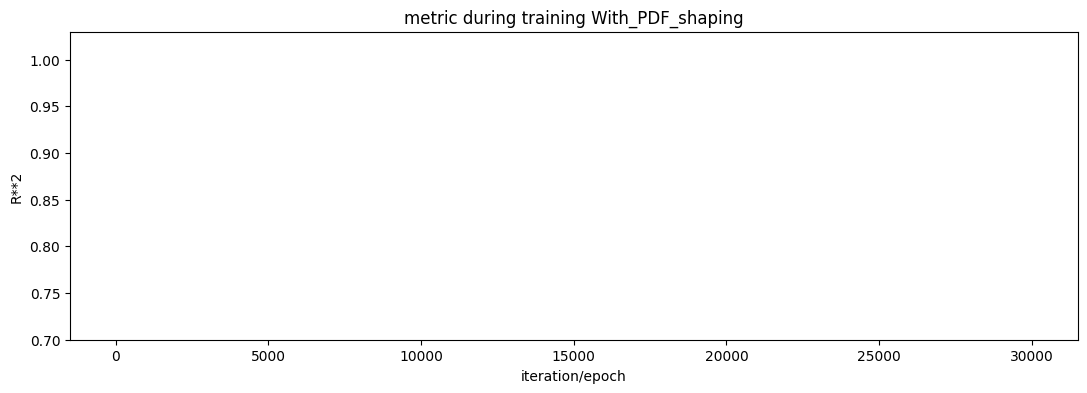

Training loss: tensor(0.3152, grad_fn=<MseLossBackward0>)
Training R**2: 0.57422988822983
Test loss - scaled: tensor(0.1173, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(359.6255, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.8428660035532872
Testing R**2 - descaled: 0.8428659988114421
*****
*****
Testing R**2 - Output: 0 o_coke_rt 0.8428659988114421


In [38]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [39]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(419.0102, 432.0)
**************************************************
preds, real
(424.2132, 424.0)
**************************************************
preds, real
(439.51874, 489.0)
**************************************************
preds, real
(324.04846, 323.0)
**************************************************
preds, real
(449.4958, 448.0)
**************************************************
preds, real
(425.2825, 424.0)
**************************************************
preds, real
(458.45605, 443.0)
**************************************************
preds, real
(422.02692, 413.0)
**************************************************
preds, real
(430.43036, 429.0)
**************************************************
preds, real
(425.8977, 435.0)
**************************************************
preds, real
(409.2938, 407.0)
**************************************************
preds, real
(345.2215, 344.0)
***********************

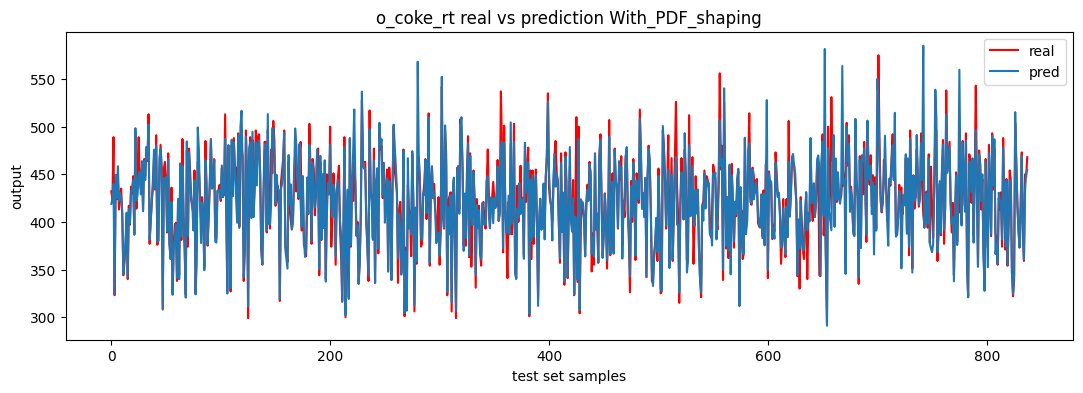

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


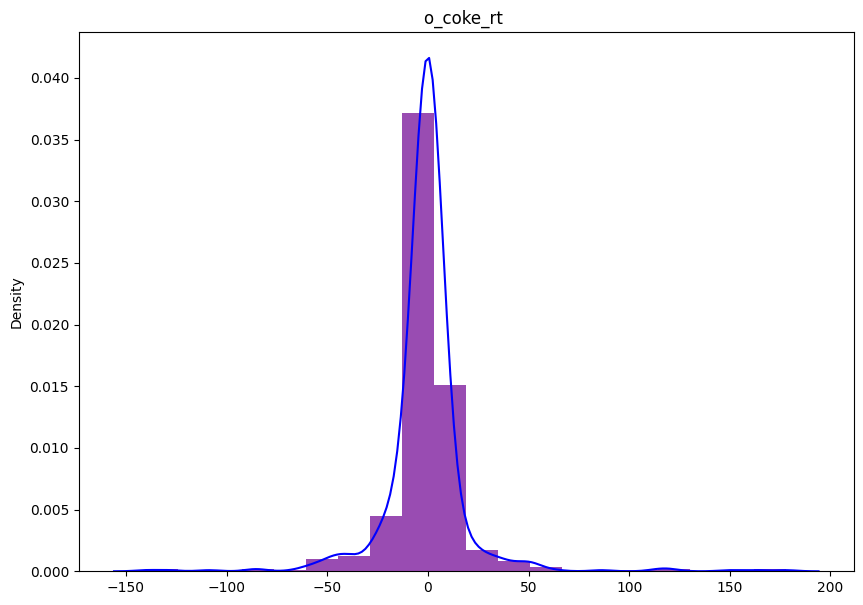

In [40]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## To compare to NNs to XGBoost


In [41]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [42]:

## y_pred

pred_descaled


tensor([[418.8025],
        [423.8615],
        [485.1648],
        [324.0484],
        [449.1386],
        [422.1512],
        [459.0049],
        [422.0542],
        [429.1665],
        [431.2246],
        [409.2968],
        [345.6146],
        [360.2801],
        [379.3082],
        [409.8068],
        [343.2268],
        [413.6078],
        [391.4953],
        [419.4361],
        [424.0200],
        [442.3592],
        [386.5582],
        [489.4263],
        [424.4853],
        [430.1586],
        [449.4599],
        [452.1831],
        [433.3757],
        [460.0200],
        [409.5923],
        [466.3088],
        [443.5362],
        [476.1030],
        [465.6113],
        [499.8124],
        [381.7474],
        [396.4460],
        [420.3597],
        [435.1404],
        [475.5287],
        [435.5605],
        [480.2448],
        [378.4500],
        [379.1569],
        [465.5264],
        [481.2296],
        [453.9964],
        [304.0742],
        [445.9687],
        [439.6567],


In [43]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.8450003694218107
Testing R**2 - descaled: 0.8450003679622049



## Export ONNX model


In [44]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [45]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [46]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [47]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3350
3350


In [48]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [49]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [50]:

y_pred


array([431.18   , 465.71255, 494.94803, 325.1585 , 447.6455 , 426.01468,
       450.27655, 439.03165, 432.0903 , 434.17175, 416.14868, 344.45013,
       340.75894, 383.44418, 415.002  , 350.82144, 418.9868 , 392.85037,
       436.69116, 430.22955, 446.66937, 384.09848, 497.01678, 413.4904 ,
       447.38763, 466.88412, 444.96268, 434.32355, 465.68048, 409.5296 ,
       465.49017, 440.7075 , 486.36917, 465.2401 , 489.26117, 394.27908,
       400.4561 , 410.20016, 426.8122 , 477.0084 , 433.58014, 496.01352,
       370.43707, 381.7628 , 471.23886, 481.74417, 449.6472 , 316.1764 ,
       439.889  , 491.77277, 511.84708, 393.9353 , 512.06647, 373.51154,
       364.56317, 427.31396, 327.52594, 366.02667, 405.3187 , 398.52975,
       344.20013, 439.9261 , 338.07452, 458.78082, 396.2007 , 478.51788,
       404.0747 , 372.99597, 325.90305, 488.3412 , 374.6111 , 475.03842,
       467.27194, 422.38803, 425.96768, 397.23123, 467.4129 , 320.45093,
       387.7077 , 457.52213, 461.1795 , 427.54388, 

In [51]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


161.4821

In [52]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.929940228079926

In [53]:

len(y_pred) 


838

In [54]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
431.18 432.0
465.71255 424.0
494.94803 489.0
325.1585 323.0
447.6455 448.0
426.01468 424.0
450.27655 443.0
439.03165 413.0
432.0903 429.0
434.17175 435.0
416.14868 407.0
344.45013 344.0
340.75894 357.0
383.44418 374.0
415.002 403.0
350.82144 340.0
418.9868 417.0
392.85037 397.0
436.69116 437.0
430.22955 430.0
446.66937 448.0
384.09848 387.0
497.01678 494.0
413.4904 414.0
447.38763 458.0
466.88412 489.0
444.96268 447.0
434.32355 435.0
465.68048 457.0
409.5296 413.0
465.49017 466.0
440.7075 448.0
486.36917 478.0
465.2401 464.0
489.26117 513.0
394.27908 377.0
400.4561 402.0
410.20016 419.0
426.8122 444.0
477.0084 468.0
433.58014 434.0
496.01352 491.0
370.43707 376.0
381.7628 380.0
471.23886 456.0
481.74417 481.0
449.6472 457.0
316.1764 308.0
439.889 456.0
491.77277 463.0
511.84708 444.0
393.9353 389.0
512.06647 472.0
373.51154 377.0
364.56317 364.0
427.31396 436.0
327.52594 326.0
366.02667 375.0
405.3187 397.0
398.52975 399.0
344.20013 338.0
439.9261 423.0
338.07452 344.0
458.

In [55]:

len( list_preds )


838

In [56]:

len( list_reals )


838

In [57]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = "o_coke_rt"


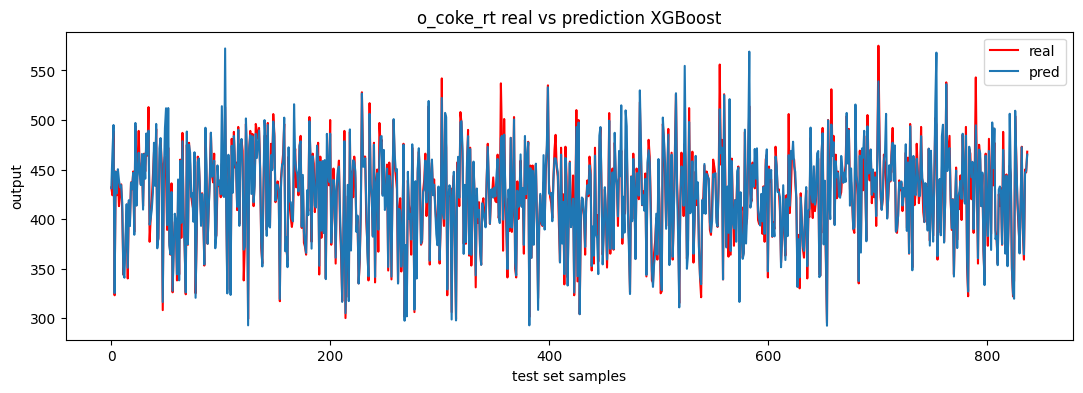

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


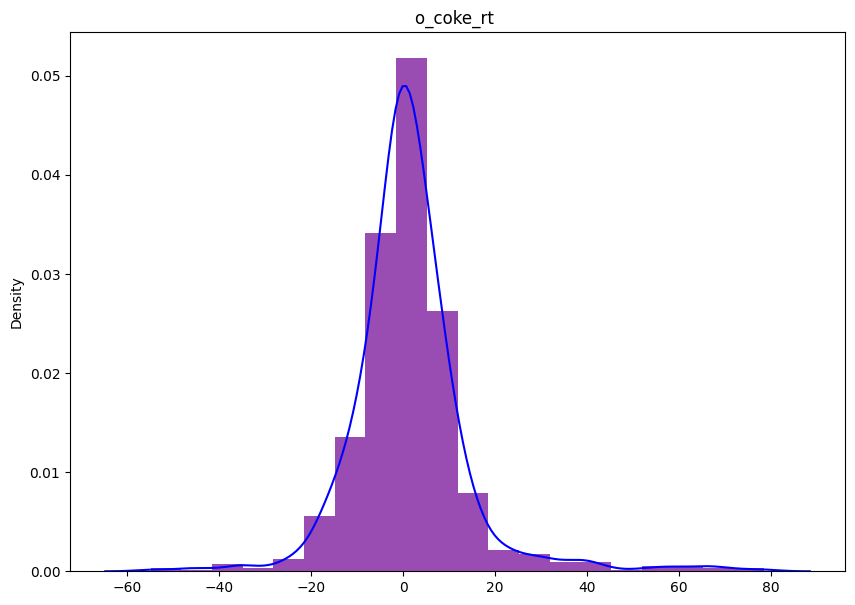

In [58]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## ONNX and XGboost


In [59]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [60]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [61]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [62]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [63]:

y_pred


array([431.18   , 465.71255, 494.94803, 325.1585 , 447.6455 , 426.01468,
       450.27655, 439.03165, 432.0903 , 434.17175, 416.14868, 344.45013,
       340.75894, 383.44418, 415.002  , 350.82144, 418.9868 , 392.85037,
       436.69116, 430.22955, 446.66937, 384.09848, 497.01678, 413.4904 ,
       447.38763, 466.88412, 444.96268, 434.32355, 465.68048, 409.5296 ,
       465.49017, 440.7075 , 486.36917, 465.2401 , 489.26117, 394.27908,
       400.4561 , 410.20016, 426.8122 , 477.0084 , 433.58014, 496.01352,
       370.43707, 381.7628 , 471.23886, 481.74417, 449.6472 , 316.1764 ,
       439.889  , 491.77277, 511.84708, 393.9353 , 512.06647, 373.51154,
       364.56317, 427.31396, 327.52594, 366.02667, 405.3187 , 398.52975,
       344.20013, 439.9261 , 338.07452, 458.78082, 396.2007 , 478.51788,
       404.0747 , 372.99597, 325.90305, 488.3412 , 374.6111 , 475.03842,
       467.27194, 422.38803, 425.96768, 397.23123, 467.4129 , 320.45093,
       387.7077 , 457.52213, 461.1795 , 427.54388, 

In [64]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.929940228079926

In [65]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [66]:

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, 'ONNXmodels/xgboost_o_coke_rt_ort.onnx')


In [67]:

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession("ONNXmodels/xgboost_o_coke_rt_ort.onnx")


In [68]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [69]:

input_name 


'float_input'

In [70]:

label_name


'variable'

In [71]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [72]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[431.17996]
 [465.71243]
 [494.94806]
 [325.15845]
 [447.64548]
 [426.0147 ]
 [450.27655]
 [439.0316 ]
 [432.0904 ]
 [434.17175]]


In [73]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [431.18    465.71255 494.94803 325.1585  447.6455  426.01468 450.27655
 439.03165 432.0903  434.17175]


In [74]:

test_cases


array([[  30. ,    0. ,    0. ,   40. ,   29. ,  300. ,  300. , 1480. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  120. ,   30. ,  300. ,    0. , 1600. ,
         230. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   24. ,  300. ,    0. , 1480. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   24. ,  700. ,    0. , 1600. ,
         195. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   27. ,  500. ,    0. , 1200. ,
         160. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,   41. ,   21. ,  700. ,    0. , 1600. ,
         230. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [   0. ,   10. ,    0. ,   40. ,   27. ,  300. ,    0. , 1480. ,
         195. ,    5.7,    5. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,   70. ,   30. ,  300. ,  300. , 1480. ,
         230. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [75]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [76]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [77]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [78]:

y_pred


array([431.18   , 465.71255, 494.94803, 325.1585 , 447.6455 , 426.01468,
       450.27655, 439.03165, 432.0903 , 434.17175, 416.14868, 344.45013,
       340.75894, 383.44418, 415.002  , 350.82144, 418.9868 , 392.85037,
       436.69116, 430.22955, 446.66937, 384.09848, 497.01678, 413.4904 ,
       447.38763, 466.88412, 444.96268, 434.32355, 465.68048, 409.5296 ,
       465.49017, 440.7075 , 486.36917, 465.2401 , 489.26117, 394.27908,
       400.4561 , 410.20016, 426.8122 , 477.0084 , 433.58014, 496.01352,
       370.43707, 381.7628 , 471.23886, 481.74417, 449.6472 , 316.1764 ,
       439.889  , 491.77277, 511.84708, 393.9353 , 512.06647, 373.51154,
       364.56317, 427.31396, 327.52594, 366.02667, 405.3187 , 398.52975,
       344.20013, 439.9261 , 338.07452, 458.78082, 396.2007 , 478.51788,
       404.0747 , 372.99597, 325.90305, 488.3412 , 374.6111 , 475.03842,
       467.27194, 422.38803, 425.96768, 397.23123, 467.4129 , 320.45093,
       387.7077 , 457.52213, 461.1795 , 427.54388, 

In [79]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.929940228079926

In [80]:

model_onnx = convert_sklearn(
    pipe, 
    'pipeline_xgboost_o_coke_rt',
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [81]:

with open("ONNXmodels/pipeline_xgboost_o_coke_rt.onnx", "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [82]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [431.18    465.71255 494.94803 325.1585  447.6455 ]


In [83]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [84]:
label_name 

'variable'

In [85]:
input_name 

'X'